# 06b — Surprise + Pattern: Does DTW Improve the Surprise Strategy? — YM

## Purpose

The original project plan ends with a three-way comparison:

> **Surprise only** vs **Surprise + State** vs **Surprise + Pattern**

Notebooks 04 and 05 covered the first two. This notebook completes the third arm. It adds a **Dynamic Time Warping (DTW)** pattern signal, the method behind the peer strategy (Jack Duncan, Hoshea Zeng), to the surprise strategy of Notebook 05.

**Question:**

> Does the *shape* of the market's price path around a release add information beyond the *surprise* itself?

**Prior evidence (stated before running):** the team has tested DTW for **direction** many times. Jack's six designs, Hoshea's generalisation test and Aaryen's features at an executable entry all failed to establish a directional DTW edge. The expected result is therefore **no improvement**. This notebook is the first test of DTW **as a confirmation of the surprise**, with our executable entry, our universe and our evaluation.

**Credits:** the DTW specification (31-minute z-scored path, same clock slot, 3-year lookback, 600 most recent, k = 15, Sakoe-Chiba band 5, 1/distance × 2-year-half-life recency weights, middle-40% rank gate) is from the peer DTW strategy (**Jack Duncan, Hoshea Zeng**). The "reaction path" ending at T+1 is Jack's design 5.

> **06b — E-mini Dow (YM).** This notebook is Notebook 06 (ES) run on **YM**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_YM.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the YM contract (tick 1 index point, $5 per point).
> - Outputs are saved as `nb06b_YM_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the YM results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Load the Notebook 05 trade log (surprise strategies and the traded releases) |
| 3 | Rebuild the release calendar and ES price measures (as in Notebook 05) |
| 4 | Build the DTW signal for every release (walk-forward, history only) |
| 5 | Diagnostics: does DTW predict the 30-minute return? Is it related to the surprise? |
| 6 | Strategies: DTW only, surprise + DTW agreement, 50/50 blend (all releases and CPI) |
| 7 | Performance, robustness and paired tests against surprise only |
| 8 | **Final three-model comparison** (Surprise only / + State / + Pattern) |

## Methodology: fixed before looking at results

**DTW signal for a release at time T.**
1. **Query path:** ES log prices from T−30 to T+1 (32 one-minute points), z-scored. It ends at the entry instant, so it includes the first minute of the market's reaction but nothing after entry.
2. **Library:** earlier releases at the **same clock time** (for example all 08:30 releases, of any type), within the last **3 years**, at most the **600** most recent, and only releases whose outcome was known at T (release time < T − 30 min).
3. **Matching:** DTW distance with a 5-minute Sakoe-Chiba band; the **15** nearest paths, weighted by 1/distance × recency (2-year half-life).
4. **Signal:** `dtw_dir` = weighted mean of the neighbours' T+1 → T+30 returns; `dtw_disp` = their weighted standard deviation; `dtw_score = dtw_dir / dtw_disp`.

**Three pre-registered strategies**, on the same releases and window as Notebook 05 (entry T+1, exit T+30):

| Strategy | Rule |
|---|---|
| **DTW only** | Trade the sign of `dtw_score` only if it is outside the middle 40% of its previous-3-year range (the peer rank gate) |
| **Surprise + DTW agreement** | Keep a surprise trade only if DTW points in the **same direction** |
| **Surprise + DTW blend** | Position = ½ × surprise position + ½ × DTW position |

The surprise baselines are Notebook 05's **All · naive** (≈10 releases) and **CPI · surprise model**. Costs, evaluation window (2019–2026) and tests are the same as Notebook 05.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "YM"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0), "YM": (1.0, 5.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
NB05_LOG = RESULTS_DIR / f"nb05b_{MARKET}_trade_log.csv"
NB05_FINAL = RESULTS_DIR / f"nb05b_{MARKET}_final_comparison.csv"
NB04_FINAL = RESULTS_DIR / f"nb04b_{MARKET}_final_comparison.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
import src.dtw_signal as ds
for m in (sc, wf, su, ds):
    importlib.reload(m)

for f in [BBG_FILE, MARKET_FILE, NB05_LOG, NB05_FINAL, NB04_FINAL]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
futures_1min_clean_v3_YM.parquet         exists: True
nb05b_YM_trade_log.csv                   exists: True
nb05b_YM_final_comparison.csv            exists: True
nb04b_YM_final_comparison.csv            exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = YM | file: futures_1min_clean_v3_YM.parquet (exists: True) | tick 1, $5 per point | cost 2 ticks + $4.50 = 2.9000 points per round trip


### 1.1 Pre-registered parameters

In [3]:
HIST_START = "2016-01-01"
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25

# DTW specification (peer strategy)
LOOKBACK_YEARS, MAX_POOL, K_NN, BAND, HALF_LIFE = 3, 600, 15, 5, 2.0
GATE_MIDDLE = 0.40          # do not trade the middle 40% of the historical score range
N_NULL, N_BOOT = 1000, 5000

SURPRISE_ALL = "All · naive"            # Notebook 05 multi-release baseline
SURPRISE_CPI = "CPI · surprise model"   # Notebook 05 CPI baseline

## 2. Load the Notebook 05 Trade Log

In [4]:
log5 = pd.read_csv(NB05_LOG)
log5["timestamp_utc"] = pd.to_datetime(log5["timestamp_utc"], utc=True)
base_all = log5[log5["strategy"] == SURPRISE_ALL].sort_values("timestamp_utc").reset_index(drop=True)
base_cpi = log5[log5["strategy"] == SURPRISE_CPI].sort_values("timestamp_utc").reset_index(drop=True)
print(f"{SURPRISE_ALL}: {len(base_all)} release timestamps, {int((base_all['position'] != 0).sum())} trades")
print(f"{SURPRISE_CPI}: {len(base_cpi)} release timestamps, {int((base_cpi['position'] != 0).sum())} trades")
display(base_all[["timestamp_utc", "families", "x", "position", "ret_bps", "cost_bps", "net_bps"]].head())

All · naive: 800 release timestamps, 738 trades
CPI · surprise model: 89 release timestamps, 66 trades


,timestamp_utc,families,x,position,ret_bps,cost_bps,net_bps
0,2019-01-03 15:00:00+00:00,ISM Manufacturing,-1.334,-1.000,-56.868,1.261,55.607
1,2019-01-04 13:30:00+00:00,Employment Report (NFP),0.663,1.000,32.749,1.264,31.485
2,2019-01-07 15:00:00+00:00,ISM Services,-0.521,-1.000,18.406,1.241,-19.647
3,2019-01-08 15:00:00+00:00,JOLTS,0.958,1.000,-46.398,1.221,-47.619
4,2019-01-29 14:00:00+00:00,Case-Shiller 20-City,-0.113,-1.000,-15.494,1.181,14.312


## 3. Release Calendar and ES Paths

In [5]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)

cal = (rows[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC")]
       .groupby("ts_utc")["clock_et"].first().reset_index().sort_values("ts_utc").reset_index(drop=True))
px = su.price_measures(es_adj, cal["ts_utc"])
cal = cal.merge(px[["ts_utc", "w1"]], on="ts_utc", how="left")

raw_paths = ds.extract_paths(es_adj, cal["ts_utc"])
paths = ds.zscore_rows(raw_paths)
ok = ~np.isnan(raw_paths).any(axis=1)
print(f"Release timestamps since {HIST_START}: {len(cal):,} | with a complete 32-minute path: {ok.sum():,} "
      f"| clock slots: {cal['clock_et'].nunique()} | {time.time()-t0:.0f}s")

# every Notebook 05 release must be in the calendar, with the same trade return
chk = base_all.merge(cal, left_on="timestamp_utc", right_on="ts_utc", how="left")
print("NB05 releases found in calendar:", chk["ts_utc"].notna().mean().round(4))
print("Max |NB05 ret - w1|:", float((chk["ret_bps"] - chk["w1"]).abs().max()))

Release timestamps since 2016-01-01: 6,097 | with a complete 32-minute path: 5,711 | clock slots: 59 | 2s
NB05 releases found in calendar: 1.0
Max |NB05 ret - w1|: 1.4210854715202004e-14


## 4. DTW Signal (walk-forward)

For every release since 2017, the 15 most similar earlier paths at the same clock time are found, using only releases whose outcome was already known. This takes about 20–60 seconds.

In [6]:
t0 = time.time()
qmask = (cal["ts_utc"] >= pd.Timestamp("2017-01-01", tz="UTC")).to_numpy()
sig = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths, cal["w1"].to_numpy(),
                            query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                            k=K_NN, band=BAND, half_life_years=HALF_LIFE)
print(f"DTW signal computed for {sig['dtw_dir'].notna().sum():,} releases in {time.time()-t0:.0f}s")
display(sig.dropna().describe().T[["count", "mean", "std", "min", "50%", "max"]])

gates = ds.gate_thresholds(sig, EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
display(pd.DataFrame(gates, index=["lower cut", "upper cut", "n history"]).T)
sig.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_dtw_signal.csv", index=False)

  DTW computed for 1,000 releases ...
  DTW computed for 2,000 releases ...
  DTW computed for 3,000 releases ...
  DTW computed for 4,000 releases ...
  DTW computed for 5,000 releases ...
DTW signal computed for 5,232 releases in 4s


,count,mean,std,min,50%,max
dtw_dir,"5,232.000",0.220,5.680,-35.624,0.140,32.867
dtw_disp,"5,232.000",17.503,11.775,0.000,15.060,105.934
pool,"5,232.000",376.505,215.595,30.000,418.000,600.000
nn_dist,"5,232.000",2.106,1.076,0.000,1.904,5.657
dtw_score,"5,232.000",0.008,0.290,-1.393,0.011,1.361


,lower cut,upper cut,n history
2019,-0.163,0.129,"1,007.000"
2020,-0.182,0.128,"1,571.000"
2021,-0.185,0.142,"1,663.000"
2022,-0.164,0.174,"1,716.000"
2023,-0.132,0.195,"1,666.000"
2024,-0.113,0.200,"1,640.000"
2025,-0.140,0.183,"1,632.000"
2026,-0.147,0.169,"1,666.000"


## 5. Diagnostics

### 5.1 Does the DTW signal predict the 30-minute return?

In [7]:
ev = sig.merge(cal[["ts_utc", "w1"]], on="ts_utc")
ev = ev[(ev["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) & ev["dtw_dir"].notna() & ev["w1"].notna()]
traded_ts = set(base_all["timestamp_utc"])
ev["in_nb05_universe"] = ev["ts_utc"].isin(traded_ts)

def ic_row(d, label):
    return dict(sample=label, n=len(d),
                rank_ic=d["dtw_score"].corr(d["w1"], method="spearman"),
                pearson_ic=d["dtw_dir"].corr(d["w1"]),
                hit_sign=(np.sign(d["dtw_dir"]) == np.sign(d["w1"])).mean())
diag = pd.DataFrame([ic_row(ev, "all releases 2019-26"),
                     ic_row(ev[ev["in_nb05_universe"]], "NB05 traded releases"),
                     ic_row(ev[ev["clock"] == "08:30"], "08:30 releases"),
                     ic_row(ev[ev["clock"] == "10:00"], "10:00 releases")]).set_index("sample")
display(diag.round(4))

yearly_ic = ev.groupby(ev["ts_utc"].dt.year).apply(lambda d: d["dtw_score"].corr(d["w1"], method="spearman")).rename("rank IC")
display(yearly_ic.to_frame().T.round(3))

,n,rank_ic,pearson_ic,hit_sign
sample,,,,
all releases 2019-26,3949,0.030,0.027,0.510
NB05 traded releases,746,0.069,0.070,0.527
08:30 releases,1051,0.034,0.042,0.504
10:00 releases,980,0.051,0.039,0.516


ts_utc,2019,2020,2021,2022,2023,2024,2025,2026
rank IC,0.010,0.010,0.045,-0.022,0.091,-0.040,0.100,0.101


**How to read it.** A rank IC around 0 means DTW has no directional information. Useful directional signals in this setting typically show an IC of about 0.05–0.10, stable across years. The hit rate should be compared with 50%.

### 5.2 Is DTW related to the surprise?

In [8]:
m = base_all.merge(sig, left_on="timestamp_utc", right_on="ts_utc", how="inner").dropna(subset=["dtw_dir", "x"])
rel = pd.Series({
    "corr(dtw_score, surprise x)": m["dtw_score"].corr(m["x"], method="spearman"),
    "share of releases where signs agree": (np.sign(m["dtw_dir"]) == np.sign(m["x"])).mean(),
    "n releases": len(m),
})
display(rel.to_frame("value").round(3))

,value
"corr(dtw_score, surprise x)",0.125
share of releases where signs agree,0.515
n releases,800.000


The DTW path ends one minute after the release, so it contains the first reaction to the surprise. A positive correlation means DTW partly **re-measures the surprise**. What matters is whether it adds information **beyond** it.

## 6. Strategies

In [9]:
def attach(base):
    t = base.merge(sig[["ts_utc", "dtw_dir", "dtw_disp", "dtw_score"]], left_on="timestamp_utc",
                   right_on="ts_utc", how="left").drop(columns="ts_utc")
    y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
    lo = y.map(lambda v: gates[v][0]); hi = y.map(lambda v: gates[v][1])
    s = t["dtw_score"]
    t["dtw_pos"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
    t["dtw_pos"] = t["dtw_pos"].fillna(0.0)
    return t

def build(base, tag):
    t = attach(base)
    out = {}
    out[f"{tag} · surprise only"] = ds.recost(t, f"{tag} · surprise only")
    d = t.copy(); d["position"] = d["dtw_pos"]
    out[f"{tag} · DTW only"] = ds.recost(d, f"{tag} · DTW only")
    a = t.copy(); a["position"] = np.where(np.sign(a["dtw_dir"]) == np.sign(a["position"]), a["position"], 0.0)
    out[f"{tag} · surprise + DTW agree"] = ds.recost(a, f"{tag} · surprise + DTW agree")
    b = t.copy(); b["position"] = 0.5 * b["position"] + 0.5 * b["dtw_pos"]
    out[f"{tag} · surprise + DTW blend"] = ds.recost(b, f"{tag} · surprise + DTW blend")
    return out

T = {**build(base_all, "All"), **build(base_cpi, "CPI")}
STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / f"nb06b_{MARKET}_trade_log.csv", index=False)
display(pd.DataFrame({k: {"trades": int((v["position"] != 0).sum()),
                          "trades / yr": (v["position"] != 0).sum() / N_YEARS} for k, v in T.items()}).T.round(1))

,trades,trades / yr
All · surprise only,738.000,98.500
All · DTW only,484.000,64.600
All · surprise + DTW agree,394.000,52.600
All · surprise + DTW blend,564.000,75.300
CPI · surprise only,66.000,8.800
CPI · DTW only,57.000,7.600
CPI · surprise + DTW agree,43.000,5.700
CPI · surprise + DTW blend,64.000,8.500


## 7. Performance

### 7.1 Main metrics (2019–2026, net of costs)

In [10]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_net_bps", "total_net_pct", "ann_return_pct",
       "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_performance.csv")
display(perf[["trades_per_year"] + KEY].round(3))

,trades_per_year,trades,hit_rate,avg_gross_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,
All · surprise only,92.614,694,0.530,2.587,1.733,12.029,1.604,2.357,1.012,0.681,-4.542,1.787,1.212
All · DTW only,61.120,458,0.535,2.129,1.268,5.805,0.774,1.640,0.791,0.472,-4.015,1.077,1.152
All · surprise + DTW agree,49.376,370,0.549,3.799,2.943,10.889,1.452,1.551,1.207,0.936,-1.656,2.121,1.365
All · surprise + DTW blend,70.328,527,0.546,2.628,2.011,10.596,1.413,1.337,1.376,1.057,-1.451,2.305,1.355
CPI · surprise only,8.808,66,0.500,5.527,4.670,3.082,0.411,0.907,0.535,0.453,-1.965,1.242,1.504
CPI · DTW only,7.340,55,0.636,5.154,4.299,2.364,0.315,0.764,0.493,0.412,-1.087,1.131,1.522
CPI · surprise + DTW agree,5.738,43,0.535,5.271,4.411,1.897,0.253,0.787,0.383,0.321,-1.225,0.879,1.426
CPI · surprise + DTW blend,8.274,62,0.565,5.228,4.571,2.834,0.378,0.740,0.582,0.511,-1.156,1.402,1.686


### 7.2 Robustness and paired comparison with surprise only

In [11]:
def sharpe_m(tr, a, b, drop_year=None):
    m = wf.monthly_returns(tr, a, b)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rows_r = []
for s in STRATS:
    base_name = s.split(" · ")[0] + " · surprise only"
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    row = dict(strategy=s, sharpe=obs,
               sharpe_2019_21=sharpe_m(T[s], "2019-01-01", "2021-12-31"),
               sharpe_2022_26=sharpe_m(T[s], "2022-01-01", EVAL_END),
               sharpe_ex_2022=sharpe_m(T[s], EVAL_START, EVAL_END, 2022),
               p_random_sign=p_null)
    if s != base_name:
        d, (lo, _, hi), p = wf.bootstrap_sharpe_diff(T[base_name], T[s], EVAL_START, EVAL_END, N_BOOT)
        pt = wf.paired_trade_test(T[base_name], T[s], EVAL_START, EVAL_END)
        row.update(sharpe_diff_vs_surprise=d, diff_ci_5=lo, diff_ci_95=hi, p_not_better=p,
                   paired_t=pt["t_stat"])
    rows_r.append(row)
rob = pd.DataFrame(rows_r).set_index("strategy")
rob.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_robustness.csv")
display(rob.round(3))

,sharpe,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign,sharpe_diff_vs_surprise,diff_ci_5,diff_ci_95,p_not_better,paired_t
strategy,,,,,,,,,,
All · surprise only,0.681,0.610,0.719,0.399,0.006,NaN,NaN,NaN,NaN,NaN
All · DTW only,0.472,0.598,0.395,0.579,0.024,-0.209,-1.337,0.762,0.668,-0.779
All · surprise + DTW agree,0.936,1.108,0.838,0.943,0.002,0.255,-0.316,0.728,0.234,-0.263
All · surprise + DTW blend,1.057,1.075,1.039,0.870,0.000,0.376,-0.027,0.732,0.063,-0.359
CPI · surprise only,0.453,0.348,0.510,-0.153,0.060,NaN,NaN,NaN,NaN,NaN
CPI · DTW only,0.412,0.522,0.391,0.184,0.068,-0.041,-0.797,0.675,0.557,-0.332
CPI · surprise + DTW agree,0.321,0.065,0.433,-0.162,0.139,-0.132,-0.485,0.187,0.760,-0.945
CPI · surprise + DTW blend,0.511,0.579,0.515,0.037,0.044,0.058,-0.254,0.374,0.393,-0.230


**How to read it.**
- **`p_not_better`** is the bootstrap probability that adding DTW is *not* better than surprise only. Below 0.05 would be convincing evidence that DTW helps.
- **`p_random_sign`** tests whether the direction beats random directions with the same trades and costs.

### 7.3 Cumulative P&L

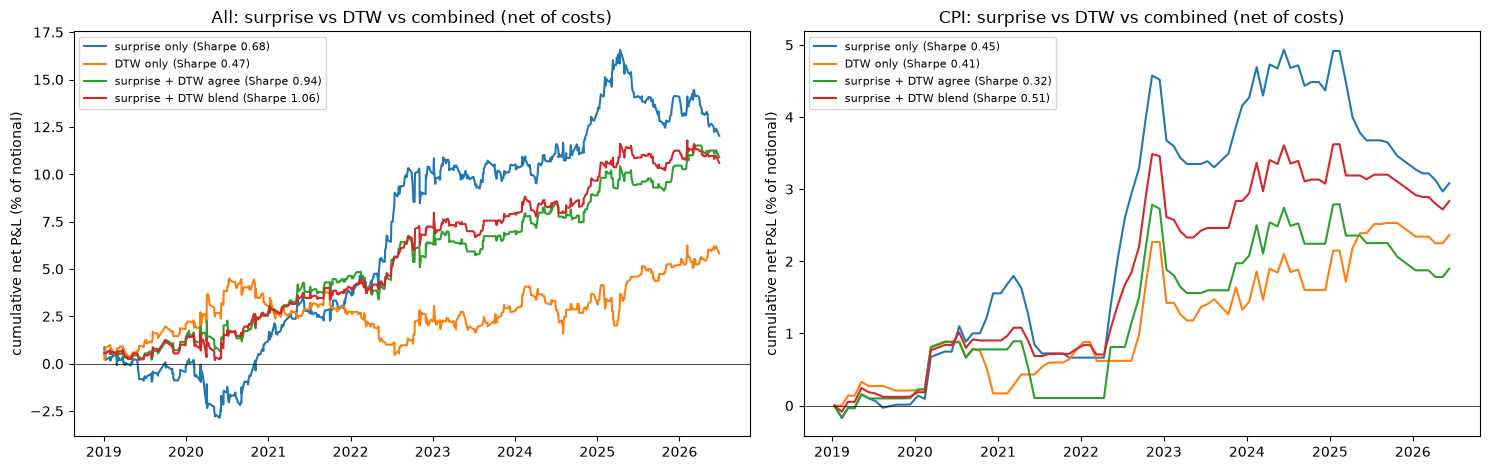

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
for ax, tag in zip(axes, ["All", "CPI"]):
    for i, suffix in enumerate(["surprise only", "DTW only", "surprise + DTW agree", "surprise + DTW blend"]):
        s = f"{tag} · {suffix}"
        cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
        ax.plot(cum.index, cum.values, lw=1.5, label=f"{suffix} (Sharpe {perf.loc[s, 'sharpe_net']:.2f})")
    ax.axhline(0, c="k", lw=0.5)
    ax.set_title(f"{tag}: surprise vs DTW vs combined (net of costs)")
    ax.set_ylabel("cumulative net P&L (% of notional)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_cumulative_pnl.png", dpi=150); plt.show()

### 7.4 When surprise and DTW disagree

In [13]:
t = attach(base_all)
t = t[(t["position"] != 0) & t["dtw_dir"].notna()]
t["net"] = t["position"] * t["ret_bps"] - t["cost_bps"]
t["dtw_agrees"] = np.sign(t["dtw_dir"]) == np.sign(t["position"])
agree_tab = t.groupby("dtw_agrees")["net"].agg(trades="size", hit_rate=lambda v: (v > 0).mean(),
                                               avg_net_bps="mean", total_net_pct=lambda v: v.sum() / 100)
display(agree_tab.round(3))

,trades,hit_rate,avg_net_bps,total_net_pct
dtw_agrees,,,,
False,344,0.480,0.347,1.124
True,394,0.515,2.941,10.883


If DTW adds information, surprise trades where **DTW agrees** should clearly beat those where it **disagrees**. Similar numbers in both rows mean DTW is not separating good trades from bad ones.

## 8. Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern

In [14]:
rows_f = []
if NB04_FINAL.exists():
    f4 = pd.read_csv(NB04_FINAL, index_col=[0, 1])
    for strat, label in [("Surprise only", "Surprise only — CPI (NB04)"),
                         ("Surprise + State", "Surprise + State — CPI (NB04)"),
                         ("Surprise + Adaptive state", "Surprise + Adaptive state — CPI (NB04)")]:
        if ("CPI", strat) in f4.index:
            r = f4.loc[("CPI", strat)]
            rows_f.append(dict(model=label, trades_per_year=r["trades"] / N_YEARS, net_bps_per_trade=r["avg_net_bps"],
                               sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"]))
for s, label in [("All · surprise only", "Surprise only — ~10 releases (NB05)"),
                 ("CPI · surprise only", "Surprise only — CPI model (NB05)"),
                 ("All · surprise + DTW agree", "Surprise + Pattern (agree) — ~10 releases"),
                 ("All · surprise + DTW blend", "Surprise + Pattern (blend) — ~10 releases"),
                 ("CPI · surprise + DTW agree", "Surprise + Pattern (agree) — CPI"),
                 ("All · DTW only", "Pattern only (DTW) — ~10 releases")]:
    r = perf.loc[s]
    rows_f.append(dict(model=label, trades_per_year=r["trades_per_year"], net_bps_per_trade=r["avg_net_bps"],
                       sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"],
                       sharpe_ex_2022=rob.loc[s, "sharpe_ex_2022"], p_random_sign=rob.loc[s, "p_random_sign"]))
rows_f.append(dict(model="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, net_bps_per_trade=1.18,
                   sharpe_net=0.613, max_dd_pct=-4.928))
final = pd.DataFrame(rows_f).set_index("model")
final.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_final_three_model_comparison.csv")
display(final.round(3))

,trades_per_year,net_bps_per_trade,sharpe_net,max_dd_pct,sharpe_ex_2022,p_random_sign
model,,,,,,
Surprise only — CPI (NB04),6.406,10.380,0.842,-1.915,NaN,NaN
Surprise + State — CPI (NB04),6.806,9.632,0.831,-1.890,NaN,NaN
Surprise + Adaptive state — CPI (NB04),7.073,8.299,0.737,-1.890,NaN,NaN
Surprise only — ~10 releases (NB05),92.614,1.733,0.681,-4.542,0.399,0.006
Surprise only — CPI model (NB05),8.808,4.670,0.453,-1.965,-0.153,0.060
Surprise + Pattern (agree) — ~10 releases,49.376,2.943,0.936,-1.656,0.943,0.002
Surprise + Pattern (blend) — ~10 releases,70.328,2.011,1.057,-1.451,0.870,0.000
Surprise + Pattern (agree) — CPI,5.738,4.411,0.321,-1.225,-0.162,0.139
Pattern only (DTW) — ~10 releases,61.120,1.268,0.472,-4.015,0.579,0.024


### 8.1 Automatic summary

In [15]:
print("=" * 100)
print(f"NOTEBOOK 06 SUMMARY — does DTW add to the surprise? ({MARKET}, 2019-2026, net of costs)")
print("=" * 100)
print("DTW directional information (rank IC vs 30-min return):")
for k, r in diag.iterrows():
    print(f"  {k:<28s} n={int(r.n):>5d}  rank IC={r.rank_ic:+.4f}  hit={r.hit_sign:.1%}")
print()
for s in STRATS:
    r = perf.loc[s]; q = rob.loc[s]
    extra = "" if pd.isna(q.get("p_not_better", np.nan)) else f" | vs surprise: ΔSharpe {q['sharpe_diff_vs_surprise']:+.2f}, P(not better) {q['p_not_better']:.2f}"
    print(f"{s:<32s} {r.trades_per_year:5.0f} tr/yr | Sharpe {r.sharpe_net:5.2f} | {r.avg_net_bps:6.2f} bps | "
          f"random-sign p {q['p_random_sign']:.3f}{extra}")

NOTEBOOK 06 SUMMARY — does DTW add to the surprise? (YM, 2019-2026, net of costs)
DTW directional information (rank IC vs 30-min return):
  all releases 2019-26         n= 3949  rank IC=+0.0301  hit=51.0%
  NB05 traded releases         n=  746  rank IC=+0.0690  hit=52.7%
  08:30 releases               n= 1051  rank IC=+0.0338  hit=50.4%
  10:00 releases               n=  980  rank IC=+0.0510  hit=51.6%

All · surprise only                 93 tr/yr | Sharpe  0.68 |   1.73 bps | random-sign p 0.006
All · DTW only                      61 tr/yr | Sharpe  0.47 |   1.27 bps | random-sign p 0.024 | vs surprise: ΔSharpe -0.21, P(not better) 0.67
All · surprise + DTW agree          49 tr/yr | Sharpe  0.94 |   2.94 bps | random-sign p 0.002 | vs surprise: ΔSharpe +0.26, P(not better) 0.23
All · surprise + DTW blend          70 tr/yr | Sharpe  1.06 |   2.01 bps | random-sign p 0.000 | vs surprise: ΔSharpe +0.38, P(not better) 0.06
CPI · surprise only                  9 tr/yr | Sharpe  0.45 |   4.

## 9. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Does DTW predict direction by itself?** Use the rank IC (Section 5.1) and the DTW-only strategy.

**2. Is DTW just re-measuring the surprise?** Use the correlation between the DTW score and the surprise (Section 5.2).

**3. Does DTW improve the surprise strategy?** Compare the agreement and blend strategies with surprise only: Sharpe difference, `P(not better)`, and agree-vs-disagree trades (Section 7.4).

**4. Final three-model answer.** Surprise only vs Surprise + State vs Surprise + Pattern: which one would you recommend, and how confident are you?

# 10. Extra Test: The Ladder: Can We Reach ~185 Trades a Year?

## Why this test

The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES** because it takes **five consecutive 30-minute trades after each release** (T+1, T+31, T+61, T+91, T+121). Our books take **one trade per release**, which caps them at about 108 trades a year on our universe.

This section copies the ladder structure to answer the supervisor's question directly:

> **If we trade five windows after each release, how many trades do we get, and what happens to the Sharpe?**

## Design (fixed before running)

| Window | Entry → exit (bars after the release) | Approx. clock time for an 08:30 release |
|---|---|---|
| 1 | close of bar T → T+29 (same as Sections 1–9) | 08:31 → 09:00 |
| 2 | T+29 → T+59 | 09:00 → 09:30 |
| 3 | T+59 → T+89 | 09:30 → 10:00 |
| 4 | T+89 → T+119 | 10:00 → 10:30 |
| 5 | T+119 → T+149 | 10:30 → 11:00 |

- **Releases:** the same ~108 release timestamps a year as Notebook 05's multi-release book.
- **DTW for window k:** the 31-minute path ending at **that window's entry**, matched against earlier releases at the same clock time, with the neighbours' **window-k** returns as the answer. Neighbours must have finished window k before the current release. The same k = 15, band, lookback, weights and middle-40% gate apply, with the gate computed separately for each window.
- **Surprise for window k:** the sign of the release's surprise (Notebook 05 naive rule), held for that window.
- **Costs:** the same round-trip cost for every window.

**Three books:**
1. **DTW ladder:** DTW in all five windows (closest to the peer structure).
2. **Surprise ladder:** the surprise sign in all five windows.
3. **Surprise W1 + DTW W2–5:** the surprise for the first window, then DTW for the later ones.

**Expected result (stated before running):** Notebook 05 found the surprise's effect is gone within about 30 minutes (window 2 Sharpe −0.79), and Section 5 found no DTW direction in window 1. We therefore expect the trade count to reach the peer's level while the Sharpe falls toward zero.

**Note:** later windows of an 08:30 release can overlap the first window of a 10:00 release on the same day. Each window is treated as a separate trade on one contract, as in the peer strategy.

## 10.1 Window returns and DTW signals for each window

In [16]:
t0 = time.time()
lad = ds.ladder_returns(es_adj, cal["ts_utc"])
assert np.nanmax(np.abs(lad["r1"].to_numpy() - cal["w1"].to_numpy())) < 1e-9, "window 1 must equal w1"
print("Window 1 identical to the Sections 1-9 trade return: OK")

sigs, lgates = {}, {}
for k, (a, b) in enumerate(ds.LADDER, start=1):
    raw_k = ds.extract_paths(es_adj, cal["ts_utc"], end_offset_min=a)
    paths_k = ds.zscore_rows(raw_k)
    sigs[k] = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths_k, lad[f"r{k}"].to_numpy(),
                                    query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                                    k=K_NN, band=BAND, half_life_years=HALF_LIFE, progress_every=0,
                                    min_gap_min=b + 1)
    lgates[k] = ds.gate_thresholds(sigs[k], EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
    print(f"Window {k} (bars {a:>3d} -> {b:>3d}): DTW computed for {sigs[k]['dtw_dir'].notna().sum():,} releases")
print(f"Done in {time.time()-t0:.0f}s")

Window 1 identical to the Sections 1-9 trade return: OK
Window 1 (bars   0 ->  29): DTW computed for 5,232 releases
Window 2 (bars  29 ->  59): DTW computed for 5,221 releases
Window 3 (bars  59 ->  89): DTW computed for 5,123 releases
Window 4 (bars  89 -> 119): DTW computed for 5,118 releases
Window 5 (bars 119 -> 149): DTW computed for 5,011 releases
Done in 21s


## 10.2 Build the ladder books

In [17]:
uni = base_all[["timestamp_utc", "position", "x", "cost_bps"]].rename(columns={"position": "surp_pos"})

def window_trades(k, rule):
    a, b = ds.LADDER[k - 1]
    t = uni.merge(lad[["ts_utc", f"r{k}"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t = t.merge(sigs[k][["ts_utc", "dtw_dir", "dtw_score"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t["ret_bps"] = t[f"r{k}"]
    if rule == "dtw":
        y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
        lo = y.map(lambda v: lgates[k][v][0]); hi = y.map(lambda v: lgates[k][v][1])
        s = t["dtw_score"]
        t["position"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
        t["position"] = pd.Series(t["position"]).fillna(0.0).to_numpy()
    else:
        t["position"] = t["surp_pos"]
    t["eligible"] = t["ret_bps"].notna()
    t["release_ts"] = t["timestamp_utc"]
    t["timestamp_utc"] = t["timestamp_utc"] + pd.Timedelta(minutes=a + 1)   # when the trade is entered
    t["window"] = k
    return ds.recost(t, f"{rule} W{k}")

W = {(rule, k): window_trades(k, rule) for rule in ["dtw", "surprise"] for k in range(1, 6)}

def book(parts, name):
    return ds.recost(pd.concat(parts).sort_values("timestamp_utc").reset_index(drop=True), name)

L = {
    "Surprise W1 only (Sections 1-9)": W[("surprise", 1)].assign(strategy="Surprise W1 only (Sections 1-9)"),
    "DTW ladder (5 windows)": book([W[("dtw", k)] for k in range(1, 6)], "DTW ladder (5 windows)"),
    "Surprise ladder (5 windows)": book([W[("surprise", k)] for k in range(1, 6)], "Surprise ladder (5 windows)"),
    "Surprise W1 + DTW W2-5": book([W[("surprise", 1)]] + [W[("dtw", k)] for k in range(2, 6)], "Surprise W1 + DTW W2-5"),
}
pd.concat(L.values()).to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_trade_log.csv", index=False)

## 10.3 Results by window

rank_ic          trades_per_year          avg_net_bps          sharpe_net         
rule                      dtw surprise             dtw surprise         dtw surprise        dtw surprise
window bars                                                                                             
1      T+0 -> T+29      0.069    0.091          61.120   92.614       1.268    1.733      0.472    0.681
2      T+29 -> T+59     0.035    0.047          57.383   92.614      -0.502   -0.394     -0.194   -0.152
3      T+59 -> T+89     0.045    0.017          58.584   92.614       0.593   -0.537      0.147   -0.180
4      T+89 -> T+119    0.010   -0.057          60.319   92.614       0.100   -2.317      0.033   -0.797
5      T+119 -> T+149  -0.065    0.042          60.186   92.614      -2.847   -0.534     -1.033   -0.298

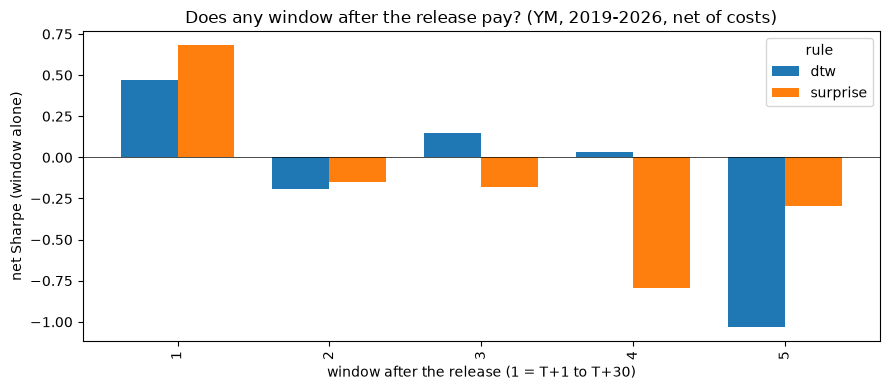

In [18]:
rows_w = []
for k in range(1, 6):
    for rule in ["surprise", "dtw"]:
        t = W[(rule, k)]
        p = wf.performance(t, EVAL_START, EVAL_END, f"{rule} W{k}")
        e = t[t["eligible"] & (t["release_ts"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
        ic = e["dtw_score"].corr(e["ret_bps"], method="spearman") if rule == "dtw" else e["x"].corr(e["ret_bps"], method="spearman")
        rows_w.append(dict(window=k, rule=rule, bars=f"T+{ds.LADDER[k-1][0]} -> T+{ds.LADDER[k-1][1]}",
                           rank_ic=ic, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                           avg_net_bps=p["avg_net_bps"], sharpe_net=p["sharpe_net"], total_net_pct=p["total_net_pct"]))
by_window = pd.DataFrame(rows_w)
by_window.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_by_window.csv", index=False)
display(by_window.pivot(index=["window", "bars"], columns="rule",
                        values=["rank_ic", "trades_per_year", "avg_net_bps", "sharpe_net"]).round(3))

fig, ax = plt.subplots(figsize=(9, 4))
piv = by_window.pivot(index="window", columns="rule", values="sharpe_net")
piv.plot.bar(ax=ax, width=0.75)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net Sharpe (window alone)")
ax.set_xlabel("window after the release (1 = T+1 to T+30)")
ax.set_title(f"Does any window after the release pay? ({MARKET}, 2019-2026, net of costs)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_ladder_sharpe_by_window.png", dpi=150); plt.show()

**How to read it.** Window 1 is the trade used in Sections 1–9. If the ladder were worth trading, windows 2–5 would show positive Sharpe and a positive rank IC. For the surprise, the rank IC is the correlation between the surprise and that window's return.

## 10.4 Ladder books: trade count vs Sharpe

,trades_per_year,hit_rate,avg_net_bps,total_net_pct,sharpe_net,sharpe_ex_2022,max_dd_pct,p_random_sign
book,,,,,,,,
Surprise W1 only (Sections 1-9),92.614,0.530,1.733,12.029,0.681,0.399,-4.542,0.006
DTW ladder (5 windows),297.591,0.502,-0.275,-6.140,-0.231,-0.136,-12.370,0.175
Surprise ladder (5 windows),463.068,0.495,-0.410,-14.217,-0.340,-0.444,-17.341,0.152
Surprise W1 + DTW W2-5,329.085,0.504,0.003,0.084,0.003,-0.138,-10.178,0.061
"Peer: Jack DTW (slide, 2018-26)",185.000,NaN,1.180,18.597,0.613,NaN,-4.928,NaN


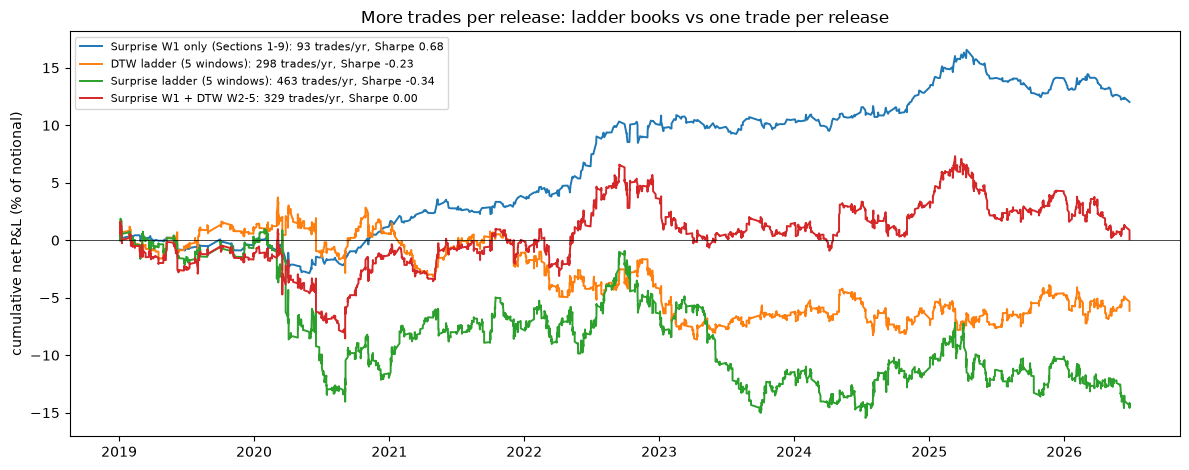

In [19]:
rows_b = []
for name, t in L.items():
    p = wf.performance(t, EVAL_START, EVAL_END, name)
    obs, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    rows_b.append(dict(book=name, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                       avg_net_bps=p["avg_net_bps"], total_net_pct=p["total_net_pct"],
                       sharpe_net=p["sharpe_net"], sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022),
                       max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
rows_b.append(dict(book="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, avg_net_bps=1.18,
                   total_net_pct=18.597, sharpe_net=0.613, max_dd_pct=-4.928))
ladder_tab = pd.DataFrame(rows_b).set_index("book")
ladder_tab.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_books.csv")
display(ladder_tab.round(3))

fig, ax = plt.subplots(figsize=(12, 4.8))
for name, t in L.items():
    cum, _ = wf.drawdown_series(t, EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, lw=1.4,
            label=f"{name}: {ladder_tab.loc[name, 'trades_per_year']:.0f} trades/yr, Sharpe {ladder_tab.loc[name, 'sharpe_net']:.2f}")
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title("More trades per release: ladder books vs one trade per release")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_ladder_cumulative.png", dpi=150); plt.show()

## 10.5 Summary of the ladder test

In [20]:
print("=" * 100)
print(f"LADDER TEST — five 30-minute windows per release ({MARKET}, 2019-2026, net of costs)")
print("=" * 100)
print("By window (net Sharpe of that window alone):")
for k in range(1, 6):
    s = by_window[(by_window.window == k) & (by_window.rule == "surprise")].iloc[0]
    d = by_window[(by_window.window == k) & (by_window.rule == "dtw")].iloc[0]
    print(f"  W{k} {s.bars:<16s} surprise: IC {s.rank_ic:+.3f}, Sharpe {s.sharpe_net:+.2f} | "
          f"DTW: IC {d.rank_ic:+.3f}, Sharpe {d.sharpe_net:+.2f}, {d.trades_per_year:.0f} tr/yr")
print("\nBooks:")
for name, r in ladder_tab.iterrows():
    print(f"  {name:<34s} {r.trades_per_year:6.0f} trades/yr | {r.avg_net_bps:6.2f} bps/trade | "
          f"Sharpe {r.sharpe_net:5.2f} | maxDD {r.max_dd_pct:6.2f}%")

LADDER TEST — five 30-minute windows per release (YM, 2019-2026, net of costs)
By window (net Sharpe of that window alone):
  W1 T+0 -> T+29      surprise: IC +0.091, Sharpe +0.68 | DTW: IC +0.069, Sharpe +0.47, 61 tr/yr
  W2 T+29 -> T+59     surprise: IC +0.047, Sharpe -0.15 | DTW: IC +0.035, Sharpe -0.19, 57 tr/yr
  W3 T+59 -> T+89     surprise: IC +0.017, Sharpe -0.18 | DTW: IC +0.045, Sharpe +0.15, 59 tr/yr
  W4 T+89 -> T+119    surprise: IC -0.057, Sharpe -0.80 | DTW: IC +0.010, Sharpe +0.03, 60 tr/yr
  W5 T+119 -> T+149   surprise: IC +0.042, Sharpe -0.30 | DTW: IC -0.065, Sharpe -1.03, 60 tr/yr

Books:
  Surprise W1 only (Sections 1-9)        93 trades/yr |   1.73 bps/trade | Sharpe  0.68 | maxDD  -4.54%
  DTW ladder (5 windows)                298 trades/yr |  -0.28 bps/trade | Sharpe -0.23 | maxDD -12.37%
  Surprise ladder (5 windows)           463 trades/yr |  -0.41 bps/trade | Sharpe -0.34 | maxDD -17.34%
  Surprise W1 + DTW W2-5                329 trades/yr |   0.00 bps/trad

### 10.6 Interpretation (fill in after running)

**1. Trade count:** how close does each ladder book get to the peer's 185 trades a year?

**2. Which windows pay?** Is window 1 the only one with a positive edge, for the surprise and for DTW?

**3. Trade count vs Sharpe:** does adding windows raise or lower the Sharpe compared with one trade per release (Sharpe 0.65 at ~98 trades a year)?

**4. Answer for the supervisor:** can we honestly reach ~185 trades a year, and at what cost in risk-adjusted return?

# Purpose, Research Questions, Answers, and Conclusion (YM)

## Purpose of Notebook 06b (YM)

Notebook 06 showed for ES that a DTW pattern signal adds no reliable directional information to the macro surprise, and Notebook 06b found the same for NQ. Notebook 05b showed that the multi-release surprise book works on YM (Sharpe 0.68, ~93 trades a year). Notebook 06b repeats Notebook 06 on the E-mini Dow:

> **Does the shape of YM's price path around a release add information beyond the surprise itself?**

**Design (identical to Notebook 06):** the peer DTW specification (31-minute z-scored path ending at entry, same clock slot, 3-year lookback, 600 most recent candidates, k = 15, Sakoe–Chiba band 5, two-year recency weighting); the DTW score is gated outside the middle 40% of its trailing three-year distribution; walk-forward 2019–2026, costs of 2 ticks + $4.50 per round trip. Nothing is re-tuned for YM.

**Data check.** 5,711 of 6,097 release timestamps since 2016 have a complete path; the DTW signal is computed for 5,232 releases in 59 clock slots. The 30-minute trade return matches Notebook 05b exactly.

### Does DTW forecast the direction of YM's next 30 minutes?

**Answer:** Weakly. The rank IC of the DTW forecast with the next 30-minute return is **+0.030** over all 3,949 releases in 2019–2026 (hit rate 51.0%) and **+0.069** on the 746 releases the surprise book trades (52.7%). By year it ranges from −0.040 (2024) to +0.101 (2025–2026) and is negative in 2 of 8 years. This is about the same weak level as in ES and NQ.

### Is DTW the same information as the surprise?

**Answer:** No. The correlation between the DTW score and the signed surprise is 0.13, and their signs agree on only 51.5% of releases, so DTW is close to independent of the surprise.

### Does combining them improve the book?

**Answer:** For the multi-release book on YM, **yes in the point estimates, but not significantly**, which is different from ES and NQ.

| Book (~10 releases) | Trades / yr | Net bps / trade | Net Sharpe | 2019–21 | 2022–26 | Ex-2022 | Max DD | vs surprise only: P(not better) |
|---|---|---|---|---|---|---|---|---|
| Surprise only (Notebook 05b) | 93 | 1.7 | 0.68 | 0.61 | 0.72 | 0.40 | −4.5% | — |
| DTW only | 61 | 1.3 | 0.47 | 0.60 | 0.40 | 0.58 | −4.0% | 0.67 |
| Surprise + DTW agree | 49 | 2.9 | 0.94 | 1.11 | 0.84 | 0.94 | −1.7% | 0.23 |
| **Surprise + DTW blend** | 70 | 2.0 | **1.06** | 1.08 | 1.04 | 0.87 | **−1.5%** | **0.06** |

When DTW agrees with the surprise, the trade earns **2.9 bps** (hit 51.5%); when it disagrees, **0.3 bps** (hit 48.0%). The blend raises the Sharpe from 0.68 to 1.06 and cuts the drawdown from −4.5% to −1.5%, and the improvement holds in both 2019–2021 and 2022–2026. But the bootstrap probability that the blend is not better than surprise only is **6%**, and that the agreement filter is not better is 23%, so neither passes a 5% test.

**For CPI alone, DTW does not help:** surprise only 0.45, DTW agree 0.32, blend 0.51 (P(not better) 0.39–0.76).

### Does DTW extend the trading window? (The ladder)

**Answer:** No. Beyond the first 30 minutes both signals lose: the surprise's second to fifth windows have Sharpe ratios of −0.15 to −0.80, and DTW's −1.03 to +0.15. The five-window DTW ladder loses (Sharpe −0.23, 298 trades a year, −12.4% drawdown), the surprise ladder loses more (−0.34), and surprise in the first window plus DTW in windows 2–5 earns nothing (0.00). On YM, as on ES and NQ, the information is spent within 30 minutes of the release.

## Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern (YM)

| Model | Trades / yr | Net Sharpe | Max DD | Verdict |
|---|---|---|---|---|
| Surprise only — CPI (Notebook 04b) | 6 | 0.84 | −1.9% | Positive, few trades |
| Surprise + State — CPI (Notebook 04b) | 7 | 0.83 | −1.9% | No improvement |
| Surprise only — ~10 releases (Notebook 05b) | 93 | 0.68 | −4.5% | The benchmark |
| **Surprise + Pattern (blend) — ~10 releases** | 70 | **1.06** | **−1.5%** | Best point estimate; P(not better) = 0.06 |
| Surprise + Pattern (agree) — ~10 releases | 49 | 0.94 | −1.7% | Better, not significant |
| Pattern only (DTW) — ~10 releases | 61 | 0.47 | −4.0% | Weaker than surprise |
| DTW 5-window ladder | 298 | −0.23 | −12.4% | Loses |

## Conclusion (YM)

1. **DTW has weak directional information on YM** (rank IC +0.03, hit rate 51%), the same level as in ES and NQ.
2. **YM is the one market where combining DTW with the surprise looks better**: the blend raises the multi-release Sharpe from 0.68 to 1.06 and cuts the drawdown by two-thirds, in both halves of the sample. In ES the agreement filter helped in 2018–2020 and hurt in 2021–2026, and in NQ no combination beat the surprise.
3. **This should not be read as a new result yet.** The improvement is not significant at 5% (P = 0.06 for the blend), it is one of several combinations tested on several markets, and it does not appear in ES or NQ with the same settings. The honest reading is that DTW may add a little on YM, and that this needs an out-of-sample check before it is used.
4. **The surprise's edge lasts about 30 minutes**, and the ladder adds only losing trades.
5. **Recommendation for YM:** keep **surprise only, first 30 minutes, ~10 releases** (Sharpe 0.68) as the main model, the same as for ES and NQ, and report the surprise + DTW blend (1.06) as a promising but unconfirmed variant.

> **Overall:** YM confirms that the macro surprise in the first 30 minutes is the robust directional signal. Unlike in ES and NQ, DTW agreement appears to improve it on YM, but the evidence is not strong enough to change the model. Notebook 07b adds YM to the multi-market portfolio.
